# RQ3, Part 4: Real Exploratory Data Analysis

Real EDA: severity balance, top auditing standards, inspection year trends, top global networks.

**Requires `pcaob_deficiencies_raw.csv` from Part 1.**

In [1]:
!pip install -q pandas matplotlib || pip install -q pandas matplotlib --break-system-packages

Real N = 17077
Real severity balance: 14043 Part I.A, 3034 Part I.B (82.2% / 17.8%)


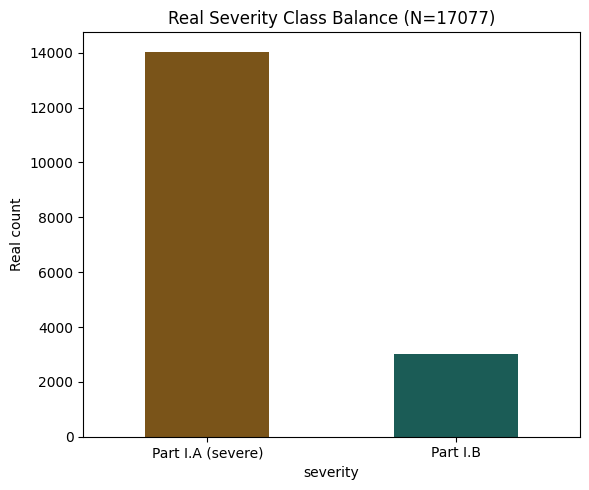

Saved rq3_eda_class_balance.png


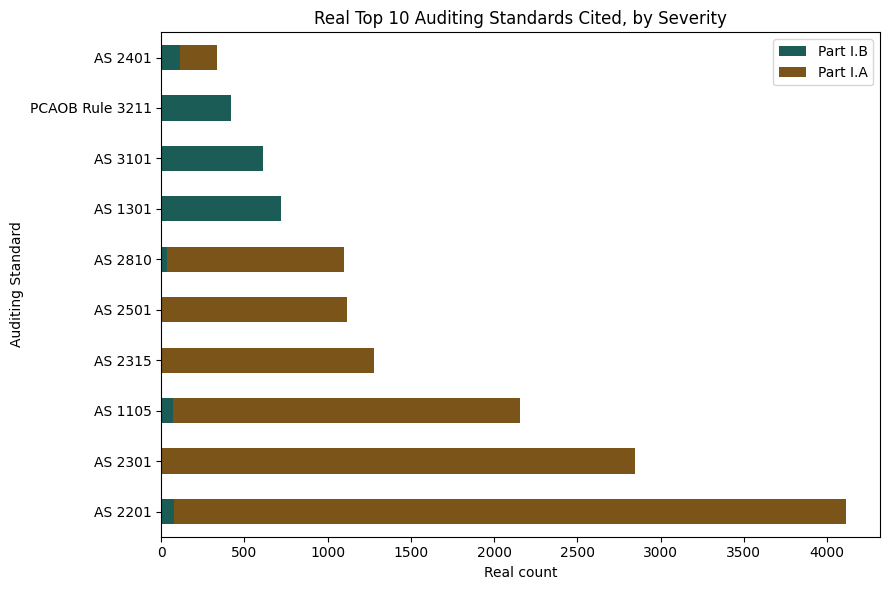

Saved rq3_eda_standards.png
Auditing Standard
AS 2201            4113
AS 2301            2849
AS 1105            2156
AS 2315            1280
AS 2501            1117
AS 2810            1096
AS 1301             718
AS 3101             612
PCAOB Rule 3211     420
AS 2401             333
Name: count, dtype: int64


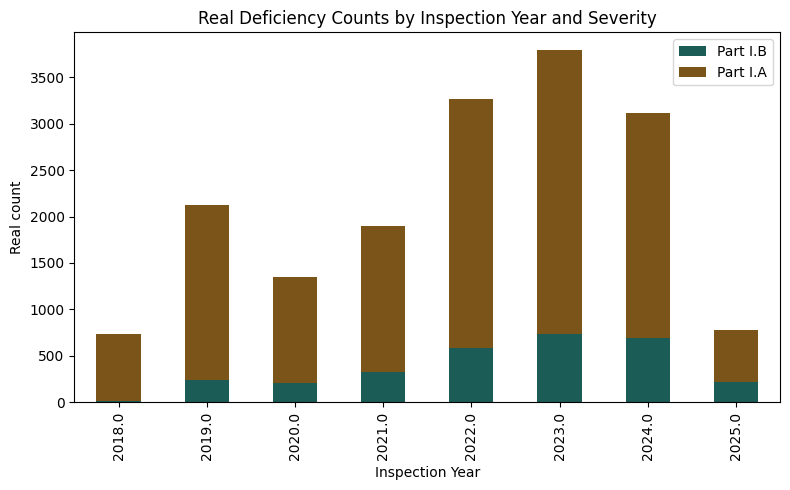

Saved rq3_eda_by_year.png


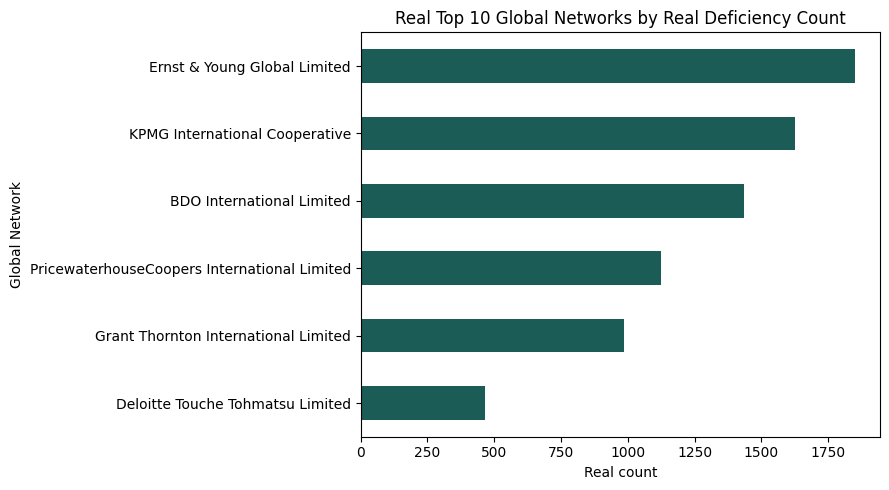

Saved rq3_eda_networks.png


In [2]:
"""
RQ3 - PART 4: Real Exploratory Data Analysis
================================================================================
Real EDA for PCAOB deficiency data: severity class balance, top real
auditing standards cited, top real global networks, and inspection year
trends -- all tailored to RQ3's actual variables.
"""
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pcaob_deficiencies_raw.csv")
print(f"Real N = {len(df)}")
print(f"Real severity balance: {(df.severity==1).sum()} Part I.A, {(df.severity==0).sum()} Part I.B "
      f"({(df.severity==1).mean()*100:.1f}% / {(df.severity==0).mean()*100:.1f}%)")

# 1. Real class balance
fig, ax = plt.subplots(figsize=(6, 5))
df["severity"].map({1: "Part I.A (severe)", 0: "Part I.B"}).value_counts().plot(
    kind="bar", ax=ax, color=["#7A5419", "#1B5C56"])
ax.set_title(f"Real Severity Class Balance (N={len(df)})")
ax.set_ylabel("Real count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rq3_eda_class_balance.png", dpi=150)
plt.show()
print("Saved rq3_eda_class_balance.png")

# 2. Top real auditing standards cited, by severity
fig, ax = plt.subplots(figsize=(9, 6))
top_standards = df["Auditing Standard"].value_counts().head(10).index
subset = df[df["Auditing Standard"].isin(top_standards)]
pd.crosstab(subset["Auditing Standard"], subset["severity"]).reindex(top_standards).plot(
    kind="barh", stacked=True, ax=ax, color=["#1B5C56", "#7A5419"])
ax.set_title("Real Top 10 Auditing Standards Cited, by Severity")
ax.set_xlabel("Real count")
ax.legend(["Part I.B", "Part I.A"])
plt.tight_layout()
plt.savefig("rq3_eda_standards.png", dpi=150)
plt.show()
print("Saved rq3_eda_standards.png")
print(df["Auditing Standard"].value_counts().head(10))

# 3. Real inspection year trend
fig, ax = plt.subplots(figsize=(8, 5))
pd.crosstab(df["Inspection Year"], df["severity"]).plot(kind="bar", stacked=True, ax=ax,
                                                            color=["#1B5C56", "#7A5419"])
ax.set_title("Real Deficiency Counts by Inspection Year and Severity")
ax.set_ylabel("Real count")
ax.legend(["Part I.B", "Part I.A"])
plt.tight_layout()
plt.savefig("rq3_eda_by_year.png", dpi=150)
plt.show()
print("Saved rq3_eda_by_year.png")

# 4. Real top global networks
fig, ax = plt.subplots(figsize=(9, 5))
df["Global Network"].value_counts().head(10).plot(kind="barh", ax=ax, color="#1B5C56")
ax.set_title("Real Top 10 Global Networks by Real Deficiency Count")
ax.set_xlabel("Real count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("rq3_eda_networks.png", dpi=150)
plt.show()
print("Saved rq3_eda_networks.png")
